# CODE TO WEBSCRAPE FROM KICKSTARTER.com
1) first of all download all the necessary libraries (there are some duplicates but I am too lazy to remove them )

In [2]:
import json
import re
import html
import ast
import random 
import numpy as np
import matplotlib.pyplot as plt
import os 
from pathlib import Path
from bs4 import BeautifulSoup
import pandas as pd 
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait 
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
import undetected_chromedriver as uc

# INSTRUCTIONS: 
- scrapde_urls.txt keeps track of every URL scraped (doesn't matter if valid description or not), so that we don't include the same one twice 
- kickstarter_scraped_all.csv accumulates only the valid projects


# Kickstarter dataset 


### First try 
I first try to use a dataset from kaggle that includes a lot of projects from kickstarter. The problem as you can clearly see here is that the description of the project is not available, the only thing available is the 'blurb' which I assume is like a very short one-line description of the project. I think it doesn't really make sense to use those for our project since as you can see in the code below, the mean length of those strings is about 18-19 letters, which seems too low for the NLP analysis we want to do

Using the Blurb is probably not enough 

### SECOND TRY 
Since the dataset doesn't work, I tried a different thing. I first tried to make a loop that basically went to the kickstarter.com website, looked at the popular page, scraped the descriptions of the projects that are on that first page, then goes to page 2 and does the same, then to page 3 and so on until it reaches n amount of descriptions saved. The problem with that was that I wasn't able to construct a loop that switched to the second page under popular and selected those projects, the loop kept only showing the first page and so only loading up to like 12 projects. 

### FINAL IDEA 

Since the above approach didn't work, I found a website that takes monthly screenshots of the whole website, the page is 'https://webrobots.io/kickstarter-datasets/', there you can find and download the zip file that contains the screenshot of the webiste for the month. In that zip there are a bunch of CSVs that need to be put together (they are different file because putting them all in one single CSV would be too large). So we first get those and put them all together and from that dataset we only want the links (these are the links to the official kickstarter page for each project), then we use these links in a loop that extracts the descriptions by webscraping and also gets the % of how much each project got funded. 


In this case just to test the code I first selected randomly 100 urls from the dataset and then webscraped the information for those

In [2]:
import pandas as pd
import glob


folder_path = "Kickstarter_2026-03-12T03_20_26_556Z"

files = glob.glob(f"{folder_path}/*.csv")

print("Number of files found:", len(files))

dfs = []

for file in files:
    print("Loading:", file)
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print("Final shape:", df.shape)

Number of files found: 85
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter001.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter002.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter003.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter004.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter005.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter006.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter007.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter008.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter009.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter010.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter011.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter012.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter013.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter014.csv
Lo

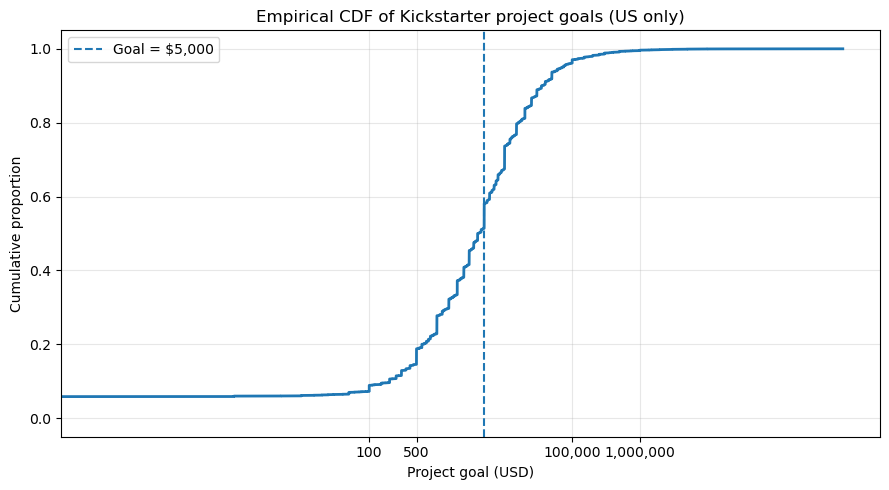

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

goals = df['goal'].dropna()

x = np.sort(goals.values)
y = np.arange(1, len(x) + 1) / len(x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, linewidth=2)
ax.axvline(5000, linestyle='--', linewidth=1.5, label='Goal = $5,000')

ax.set_xscale('log')

ticks = [100, 500, 100000, 1000000]
ticks = [t for t in ticks if x.min() <= t <= x.max()]
ax.set_xticks(ticks)
ax.set_xticklabels([f'{t:,.0f}' for t in ticks])
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel('Project goal (USD)')
ax.set_ylabel('Cumulative proportion')
ax.set_title('Empirical CDF of Kickstarter project goals (US only)')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
df

,backers_count,blurb,category,converted_pledged_amount,country,country_displayable_name,created_at,creator,currency,currency_symbol,...,spotlight,staff_pick,state,state_changed_at,static_usd_rate,urls,usd_exchange_rate,usd_pledged,usd_type,video
0,2,Built for the Pump. Tailored to Fit. esc4pe Gy...,"{""id"":269,""name"":""Ready-to-wear"",""analytics_na...",146.0,DE,Germany,1751226756,"{""id"":865203874,""name"":""esc4pe gymwear"",""slug""...",EUR,€,...,False,False,failed,1757527203,1.166456,"{""web"":{""project"":""https://www.kickstarter.com...",1.170848,145.806942,domestic,"{""id"":1377608,""status"":""successful"",""hls"":""htt..."
1,1,Tech Meets Totem: High-Tech &Advanced-Stain-Re...,"{""id"":269,""name"":""Ready-to-wear"",""analytics_na...",115.0,CA,Canada,1752282286,"{""id"":721218801,""name"":""Jessica Lyu"",""is_regis...",CAD,$,...,False,False,failed,1757049287,0.725141,"{""web"":{""project"":""https://www.kickstarter.com...",0.724257,116.022488,domestic,"{""id"":1375141,""status"":""successful"",""hls"":""htt..."
2,11,Sharing joy and cuteness via images of baby go...,"{""id"":353,""name"":""Stationery"",""analytics_name""...",482.0,US,the United States,1674844300,"{""id"":1717046955,""name"":""Teresa Oliver"",""slug""...",USD,$,...,True,False,successful,1678331521,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,482.000000,domestic,NaN
3,35,Intel Ultra CPU | Integrated AI-Enhanced GPU &...,"{""id"":52,""name"":""Hardware"",""analytics_name"":""H...",48555.0,US,the United States,1721269019,"{""id"":914589792,""name"":""Giada Tech"",""slug"":""gi...",USD,$,...,True,False,successful,1727359213,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,48555.000000,domestic,"{""id"":1309417,""status"":""successful"",""hls"":""htt..."
4,227,Compact Design. Multi-function. Simplify Life....,"{""id"":28,""name"":""Product Design"",""analytics_na...",17957.0,HK,Hong Kong,1723352304,"{""id"":240625457,""name"":""EckDesign"",""slug"":""eck...",HKD,$,...,True,False,successful,1727359082,0.128287,"{""web"":{""project"":""https://www.kickstarter.com...",0.128451,17934.284200,domestic,"{""id"":1307319,""status"":""successful"",""hls"":""htt..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268534,8,We are healing the world one immersive experie...,"{""id"":332,""name"":""Apps"",""analytics_name"":""Apps...",761.0,US,the United States,1750357647,"{""id"":755375393,""name"":""Tricia Keightley"",""slu...",USD,$,...,False,False,failed,1753562000,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,761.000000,domestic,"{""id"":1369696,""status"":""successful"",""hls"":""htt..."
268535,7,A unique project that revolutionizes working o...,"{""id"":332,""name"":""Apps"",""analytics_name"":""Apps...",1443.0,US,the United States,1750679728,"{""id"":1072886381,""name"":""Taco Fleur"",""slug"":""k...",USD,$,...,False,False,failed,1752693465,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,1443.000000,domestic,"{""id"":1369574,""status"":""successful"",""hls"":""htt..."
268536,106,The Wall 2061 is a city-wide live-action rolep...,"{""id"":271,""name"":""Live Games"",""analytics_name""...",6788.0,DE,Germany,1506518699,"{""id"":257137944,""name"":""Gamestorm Berlin"",""slu...",EUR,€,...,True,True,successful,1519376417,1.225988,"{""web"":{""project"":""https://www.kickstarter.com...",1.230158,6764.999025,domestic,"{""id"":852289,""status"":""successful"",""hls"":null,..."
268537,15,"A son needs money from his rich, estranged fat...","{""id"":31,""name"":""Narrative Film"",""analytics_na...",3600.0,US,the United States,1448311257,"{""id"":870950346,""name"":""Anthony Riso"",""is_regi...",USD,$,...,True,False,successful,1450976401,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,3600.000000,domestic,"{""id"":616283,""status"":""successful"",""hls"":null,..."


In [4]:

category_names = []

for item in df['category']:
    parsed = json.loads(item)
    name = parsed['name']
    if name not in category_names:
        category_names.append(name)

print(category_names, len(category_names))


parent_names = set()

for item in df['category']:
    parsed = ast.literal_eval(item)
    if 'parent_name' in parsed:
        parent_names.add(parsed['parent_name'])

print(parent_names)
print(len(parent_names))

category_counts = {}

for item in df['category']:
    parsed = ast.literal_eval(item)
    if 'parent_name' in parsed:
        parent = parsed['parent_name']
        if parent in category_counts:
            category_counts[parent] += 1
        else:
            category_counts[parent] = 1

print(category_counts)



['Ready-to-wear', 'Stationery', 'Hardware', 'Product Design', 'Web', 'Indie Rock', 'Puzzles', 'Anthologies', 'Art Books', 'Apparel', 'Television', 'Wearables', 'Accessories', 'Mobile Games', 'Comedy', 'Science Fiction', 'DIY', 'DIY Electronics', 'Jewelry', 'Academic', 'Textiles', 'Horror', 'Comic Books', 'Drama', 'Hip-Hop', 'Video Games', 'Tabletop Games', 'Playing Cards', 'Pottery', 'Pet Fashion', 'Thrillers', 'Shorts', 'Graphic Novels', 'Fabrication Tools', 'Illustration', 'Performance Art', 'People', 'Faith', 'Classical Music', 'Gadgets', 'Sound', 'Experimental', 'Zines', 'Apps', 'Mixed Media', 'Woodworking', '3D Printing', 'Country & Folk', 'Robots', 'Technology', 'Metal', 'Animation', 'Immersive', 'Family', 'Performances', 'Webseries', 'Fiction', 'Fantasy', 'Kids', 'Software', 'Documentary', 'Live Games', "Children's Books", 'Architecture', 'Young Adult', 'Toys', 'Photobooks', 'Small Batch', 'Bacon', 'Fine Art', 'Music', 'Literary Journals', 'Nonfiction', 'Photography', 'Punk', 'D

12k projects => 10 categories 
15k => 7 categories 
20k => 6 categories 
22k => 5 categories 

In [5]:
final_categories = {}
for item in category_counts:
    if category_counts[item] > 22000:
        final_categories[item] = category_counts[item]

final_categories

{'Technology': 24149,
 'Music': 30156,
 'Games': 24781,
 'Publishing': 29262,
 'Film & Video': 34861}

# POLISHING THE DATASET 

In [6]:
copy = df[df['country'] == 'US']
copy = copy[copy['usd_pledged'] > 0]
copy['pct_goal_reached'] = (copy['usd_pledged'] / copy['goal']) * 100
copy = copy[copy['pct_goal_reached'] > 1]
copy = copy[copy['usd_pledged'] == copy['converted_pledged_amount']]
copy = copy[copy['state'] != 'canceled']

copy = copy[copy['goal'] > 5000]


def get_parent_name(item):
    parsed = ast.literal_eval(item)
    return parsed.get('parent_name', None)

copy['parent_name'] = copy['category'].apply(get_parent_name)
copy = copy[copy['parent_name'].isin(final_categories.keys())]

len(copy)

25325

In [7]:
copy.iloc[4,1]

"Automatically Activated Audio/Visual Beacon for Fire Emergencies (attaches to pet's collar). Activated by ANY Fire Alarm."

In [8]:
def extract_project_url(x):
    if pd.isna(x):
        return None
    try:
        d = json.loads(x)
        return d.get("web", {}).get("project")
    except:
        return None
    
copy["project_url"] = copy['urls'].apply(extract_project_url)

print(copy["project_url"].notna().sum())
print(copy["project_url"].dropna().head())

25325
27    https://www.kickstarter.com/projects/blackball...
36    https://www.kickstarter.com/projects/claw/elec...
42    https://www.kickstarter.com/projects/boltind/b...
56    https://www.kickstarter.com/projects/181882321...
63    https://www.kickstarter.com/projects/selfascop...
Name: project_url, dtype: object


# here is the code to actually run the loop for all the urls you extracted in project_urls: 


## NOT SO RANDOM Sampling: 


In [16]:
df_valid = copy[copy['project_url'].notna()]
# If a tracking file exists, load already-scraped URLs
if os.path.exists('scraped_urls.txt'):
    with open('scraped_urls.txt', 'r') as f:
        scraped_urls = set(f.read().splitlines())
else:
    scraped_urls = set()


# Filter out already-scraped URLs
df_remaining = df_valid[~df_valid["project_url"].isin(scraped_urls)]
print(f"Already scraped: {len(scraped_urls)}")
print(f"Remaining: {len(df_remaining)}")
print(df_remaining['parent_name'].value_counts())

Already scraped: 4272
Remaining: 19150
parent_name
Music           5988
Film & Video    5790
Publishing      3151
Technology      3051
Games           1170
Name: count, dtype: int64


In [17]:
len(df_remaining)

19150

In [18]:
n_categories = df_remaining['parent_name'].nunique()
batch_size = 500

n_per_category = batch_size // n_categories

sample_balanced = (
    df_remaining
    .groupby('parent_name')
    .sample(n=n_per_category)
)

batch_urls = sample_balanced["project_url"].tolist()
print(f"Categories: {n_categories}, per category: {n_per_category}, total: {len(batch_urls)}")
print(sample_balanced['parent_name'].value_counts())
print(len(batch_urls), 'projects :', batch_urls)

Categories: 5, per category: 100, total: 500
parent_name
Film & Video    100
Games           100
Music           100
Publishing      100
Technology      100
Name: count, dtype: int64
500 projects : ['https://www.kickstarter.com/projects/887731335/circle-feature-film', 'https://www.kickstarter.com/projects/1019896413/glazed-a-columbia-university-thesis-film', 'https://www.kickstarter.com/projects/1100509927/we-want-some', 'https://www.kickstarter.com/projects/777161259/the-pages-of-destiny', 'https://www.kickstarter.com/projects/686608829/dirty-laundry-tv-indie-music-web-series', 'https://www.kickstarter.com/projects/1048486202/step-into-the-world-of-lars-van-de-goor', 'https://www.kickstarter.com/projects/brandontobatto/splatter-camptm', 'https://www.kickstarter.com/projects/fullspectrum/the-orange-story-a-cinematic-digital-history-proje', 'https://www.kickstarter.com/projects/romancepackagefortwo/romance-package-for-two-a-short-film', 'https://www.kickstarter.com/projects/johnsimone/c

In [19]:

def scrape_kickstarter_description(url: str) -> dict:
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu") 
    options.add_argument("--window-size=1920,1080")       
    options.add_argument("--disable-extensions")          
    options.add_argument("--disable-software-rasterizer")  
    options.add_argument("--remote-debugging-port=0")     
    options.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )

    try:
        driver.get(url)

        WebDriverWait(driver, 15).until(
            EC.presence_of_element_located((By.CLASS_NAME, "rte__content"))
        )

        time.sleep(2)
        html_source = driver.page_source
        soup = BeautifulSoup(html_source, "html.parser")

        
        description_div = soup.find("div", class_="rte__content")
        description = (
            description_div.get_text(separator=" ", strip=True)
            if description_div else None
        )

        
        title = soup.find("h1", class_="project-name")
        if not title:
            title = soup.find("h2")
        title = title.get_text(strip=True) if title else None

        funding = {
            "pledged": None,
            "usd_pledged": None,
            "converted_pledged_amount": None,
            "goal": None,
            "currency": None
        }

        for script in soup.find_all("script"):
            script_text = script.string or script.get_text()
            if "window.current_project" not in script_text:
                continue

            match = re.search(
                r'window\.current_project\s*=\s*"(.+?)";',
                script_text,
                re.DOTALL
            )
            if not match:
                continue

            raw = match.group(1)

            raw = html.unescape(raw)
            try:
                raw = raw.encode("utf-8").decode("unicode_escape")
            except Exception: 
                pass

            try:
                project_data = json.loads(raw)
                funding = {
                    "pledged": project_data.get("pledged"),
                    "usd_pledged": project_data.get("usd_pledged"),
                    "converted_pledged_amount": project_data.get("converted_pledged_amount"),
                    "goal": project_data.get("goal"),
                    "currency": project_data.get("currency")
                }
                break
            except json.JSONDecodeError:
                pass

    finally:
        driver.quit()

    return {
        "url": url,
        "title": title,
        "description": description,
        **funding
    }





In [20]:
MIN_DESCRIPTION_LENGTH = 800
output_file = 'kickstarter_scraped_all.csv'
rows = []

for i, url in enumerate(batch_urls, start=1):
    print(f"Scraping {i}/{len(batch_urls)}: {url}")
    
    try:
        row = scrape_kickstarter_description(url)
    except Exception as e:
        print(f"  ✗ Error scraping {url}: {e}")
        continue

    desc = row.get("description")
    if desc and len(desc) >= MIN_DESCRIPTION_LENGTH:
        rows.append(row)
        scraped_urls.add(url)
        print(f"  ✓ Saved (length: {len(desc)})")
        time.sleep(random.uniform(4, 9))
    else:
        print(f"  ⚠ Skipped (description too short or missing)")

    if i % 10 == 0:
        if rows:
            pd.DataFrame(rows).to_csv(output_file, mode='a', header=not os.path.exists(output_file), index=False)
            rows = []  # clear rows after saving to avoid duplicates
        with open('scraped_urls.txt', 'w') as f:
            f.write('\n'.join(scraped_urls))
        print(f"  💾 Progress saved at {i}/{len(batch_urls)}")

    

if rows:
    pd.DataFrame(rows).to_csv(output_file, mode='a', header=not os.path.exists(output_file), index=False)

with open('scraped_urls.txt', 'w') as f:
    f.write('\n'.join(scraped_urls))

print(f"\nBatch complete.") 
print(f"Total URLs scraped so far: {len(scraped_urls)}")

Scraping 1/500: https://www.kickstarter.com/projects/887731335/circle-feature-film
  ✗ Error scraping https://www.kickstarter.com/projects/887731335/circle-feature-film: Message: 
Stacktrace:
	chromedriver!GetHandleVerifier [0x42cdf3+10b03]
	chromedriver!GetHandleVerifier [0x42cf24+10c34]
	chromedriver!(No symbol) [0x212120]
	chromedriver!(No symbol) [0x25abca]
	chromedriver!(No symbol) [0x25ae6b]
	chromedriver!(No symbol) [0x29d0b2]
	chromedriver!(No symbol) [0x27db54]
	chromedriver!(No symbol) [0x29a9a5]
	chromedriver!(No symbol) [0x27d8a6]
	chromedriver!(No symbol) [0x250229]
	chromedriver!(No symbol) [0x250fe4]
	chromedriver!GetHandleVerifier [0x6948b9+2785c9]
	chromedriver!GetHandleVerifier [0x68feb5+273bc5]
	chromedriver!GetHandleVerifier [0x6ae06b+291d7b]
	chromedriver!GetHandleVerifier [0x445cc8+299d8]
	chromedriver!GetHandleVerifier [0x44d9fd+3170d]
	chromedriver!GetHandleVerifier [0x4358c8+195d8]
	chromedriver!GetHandleVerifier [0x435a92+197a2]
	chromedriver!GetHandleVerifier

KeyboardInterrupt: 

In [5]:
file = pd.read_csv('kickstarter_scraped_all.csv')

In [6]:
file

,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,5137.0,4449,15000.0,USD
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50640.0,43865,50000.0,USD
...,...,...,...,...,...,...,...,...
4256,https://www.kickstarter.com/projects/170544040...,Categories,Gamer Badges GAMER BADGES are real life badges...,11781.0,11781.0,10101,7500.0,USD
4257,https://www.kickstarter.com/projects/questform...,Quest for Melody,"In the mystical world of Harmony, a land bless...",227.0,227.0,194,20000.0,USD
4258,https://www.kickstarter.com/projects/flyinghor...,Honest Dice | Precision Machined Metal Dice Yo...,Late pledges are now open! These dice feature ...,712506.0,712506.0,610921,10000.0,USD
4259,https://www.kickstarter.com/projects/mmcdonald...,Versa+Play by S23D LLC,Overview Welcome to the Kickstarter campaign f...,332.0,332.0,284,8200.0,USD


In [7]:
mean_length = file["description"].str.len().mean()
min_length = file["description"].str.len().min()
max_length = file["description"].str.len().max()
print('mean :', mean_length)
print('max :', max_length)
print('min :', min_length)

mean : 6033.498005163107
max : 35273
min : 802


saving them in a dataset:

Possible NLP Tasks: 
- classification: classify based on description if campaing reaches x% of funding or 100% of funding (TF-IDF and logistic regression or BERT CLassifier) 
- Topic modelling: identify the main topics from each campaign and do what? 
- Embedding analysis: either transform all the descriptions into vectors with doc2vec and do clusters based on cosine distance (maybe also compare which cluster has higher funding)
- Generative Task: take a real campaign and ask to rewrite it in a more persuasive tone or just better, then feed into the initial classifier and test if gets better classification 

NOTEs

- thing that she would like to see is a preliminary analysis on the data
- don't take two weeks to download the data 


In [7]:
rohan = pd.read_csv('kickstarter_rohan.csv')
ste = pd.read_csv('kickstarter_ste.csv')
lore = pd.read_csv('kickstarter_lorenzo.csv')


In [21]:
rohan

,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency
0,https://www.kickstarter.com/projects/723988444...,Categories,Hi Everyone! Thanks so much for visiting our K...,8865.0,8865.0,7694,8399.0,USD
1,https://www.kickstarter.com/projects/nylecavaz...,'CATnip' The Movie,"Hello Kickstarter Community, welcome to the wo...",69817.0,69817.0,60602,66666.0,USD
2,https://www.kickstarter.com/projects/tracesfro...,Traces From the Attic- Feature Film,"After being the only child, James was finally ...",1546.0,1546.0,1341,25000.0,USD
3,https://www.kickstarter.com/projects/herringbo...,Categories,"Deep in the frozen tundra of Northern Canada, ...",33442.0,33442.0,29028,30000.0,USD
4,https://www.kickstarter.com/projects/adrianave...,Categories,We did it! WE HIT 100% ... and it's all thanks...,49214.0,49214.0,42718,45000.0,USD
...,...,...,...,...,...,...,...,...
324,https://www.kickstarter.com/projects/breast-ve...,Breast-Vest,I am raising funds to help go towards creating...,602.0,602.0,516,7500.0,USD
325,https://www.kickstarter.com/projects/190668810...,Categories,Windows 11 Pro comes with a modern design and ...,462278.0,462278.0,396369,100000.0,USD
326,https://www.kickstarter.com/projects/neopenda/...,Categories,Praise for Neopenda! Our mission: improve newb...,40953.0,40953.0,35114,40000.0,USD
327,https://www.kickstarter.com/projects/roamrelay...,RoamRelay: a Social Travel companion app,Introducing RoamRelay: Navigate. Personalize. ...,501.0,501.0,429,25000.0,USD


In [24]:
merged = pd.concat([ste, file, rohan, lore, barbara], ignore_index=True)
num_duplicates = merged.duplicated().sum()
print(f"Duplicate rows: {num_duplicates}")

merged = merged.drop_duplicates()
merged.to_csv('kickstarter_dataset.csv')

Duplicate rows: 1042


In [9]:
len(merged[merged['description'].notna()])
mean_length = merged["description"].str.len().mean()
min_length = merged["description"].str.len().min()
max_length = merged["description"].str.len().max()
print('mean :', mean_length)
print('max :', max_length)
print('min :', min_length)

mean : 5905.94962431694
max : 35273.0
min : 802.0


In [9]:
barbara = pd.read_csv('scraped_Barbara.csv')

In [10]:
barbara

,https://www.kickstarter.com/projects/bodycountfilm/body-count-one-shot-entertainments-first-feature-film,Body Count - One Shot Entertainment's First Feature Film,"DO YOU LIKE SCARY MOVIES? Daniel Irwin, Kieran Sherry, Jake Ruderman (Left to right) Hey! We’re One Shot Entertainment, a group of young indie filmmakers and lifelong friends. We’ve grown up telling stories, made a slew of short films that have gotten into film festivals, and been awarded for our work. But we're not satisfied. This summer, we're looking to begin production on our first feature! Body Count is the ultimate love letter to horror. Whether it was watching Sinister (The only horror movie to ever unsettle us) at a sleepover in middle school, or convincing our parents to take us to Stephen King’s It , we were raised on scary movies. With Body Count, a decade and world-hopping examination of the horror genre, we don’t just want to honor the legacy of horror, we want to be a part of it. And YOU can help make that happen. WE'RE GONNA NEED A BIGGER BUDGET! To get this film moving, we're looking to raise $20,000. This amount's nothing to sneeze at, but for a feature film, it is incredibly low. This initial $20,000 will allow us to approach seasoned producers and investors to raise the rest of our ideal budget. We're also planning on shooting this feature in our hometown of Kingston, Pennsylvania, where we don't have to worry about many of the typical expenses. All of the film's primary locations have been secured, we've been in touch with several leading actors with interest in the project, and we've begun to assemble a small but mighty crew. Body Count 's writer and One Shot's own, Kieran Sherry, is thrilled to be making his directorial debut, and we're thrilled to have him at the helm! All of these advantages allow our budget to be focused primarily on securing the best equipment possible, shoring up the remaining cast and crew, and allowing for the use of makeup and practical effects, the heart and soul of independent horror! THIS IS NO DREAM! THIS IS REALLY HAPPENING! So why does Body Count need your help? Under our current circumstances, we can't bring Body Count to life in the way we know it needs to be. A proper budget is crucial to realizing our vision for this horror odyssey. The script is in great condition, and the on-screen and off-screen talent already attached are talented and dedicated. All that's left is a budget! Once the film is completed, we intend to pursue distribution and bring Body Count to as wide an audience as possible. We truly believe Body Count has a unique perspective on the horror genre and its most under-appreciated stereotype, which will resonate with any horror fan. TRUST'S A TOUGH THING TO COME BY THESE DAYS Despite our need for a larger budget, we know and understand that not everyone can contribute. That doesn't mean there aren’t ways you can help Body Count ! If you have other friends who are fans of horror or independent film, spread the news! Any contribution helps. If you have any experience in the filmmaking process, feel free to reach out - we’re still looking for several on-set and post-production roles. Also, check us out at One Shot Entertainment on Instagram, TikTok, and YouTube to see some of our other films and to stay up to date on Body Count !",4475.0,4475.0.1,3877,20000.0,USD
0,https://www.kickstarter.com/projects/strokedoc...,Stroke: a Survival and Recovery Story,My name is Brandon Schuster. I am part of 159 ...,1318.0,1318.0,1142,30000.0,USD
1,https://www.kickstarter.com/projects/shelbynic...,"feathers, not wings - An Animated Short Film",UPDATE: We are aiming to reach our stretch goa...,51836.0,51836.0,44918,40000.0,USD
2,https://www.kickstarter.com/projects/141313877...,The Herb Chronicles - Adult Animated Series - ...,The Herb Chronicles follows the story of three...,2224.0,2224.0,1927,9999.0,USD
3,https://www.kickstarter.com/projects/dreadsout...,The Dread South: A Miniseries,STORY: What is the Dread Sout

In [22]:
# Step 1: Reset — move current column names back into row 0
barbara = pd.DataFrame(
    [barbara.columns.tolist()] + barbara.values.tolist(),
    columns=['url',	'title', 'description',	'pledged','usd_pledged', 'converted_pledged_amount', 'goal', 'currency']  # ← your new column names here
)

In [23]:
barbara

,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency
0,https://www.kickstarter.com/projects/bodycount...,Body Count - One Shot Entertainment's First Fe...,"DO YOU LIKE SCARY MOVIES? Daniel Irwin, Kieran...",4475.0,4475.0.1,3877,20000.0,USD
1,https://www.kickstarter.com/projects/strokedoc...,Stroke: a Survival and Recovery Story,My name is Brandon Schuster. I am part of 159 ...,1318.0,1318.0,1142,30000.0,USD
2,https://www.kickstarter.com/projects/shelbynic...,"feathers, not wings - An Animated Short Film",UPDATE: We are aiming to reach our stretch goa...,51836.0,51836.0,44918,40000.0,USD
3,https://www.kickstarter.com/projects/141313877...,The Herb Chronicles - Adult Animated Series - ...,The Herb Chronicles follows the story of three...,2224.0,2224.0,1927,9999.0,USD
4,https://www.kickstarter.com/projects/dreadsout...,The Dread South: A Miniseries,STORY: What is the Dread South? The Dread Sout...,220.0,220.0,190,13000.0,USD
...,...,...,...,...,...,...,...,...
1861,https://www.kickstarter.com/projects/jacobzirk...,VFX Oasis: Free VFX Assets and Footage,What is VFX Oasis? VFX Oasis is an industry fo...,580.0,580.0,496,6000.0,USD
1862,https://www.kickstarter.com/projects/153189407...,Sharp X - Edge Gadget,Kickstarter Project Story – USA-Market Sharpen...,857.0,857.0,734,7800.0,USD
1863,https://www.kickstarter.com/projects/diyengine...,Steady Shot Bot: Hyperlapse + Steadycam + Auto...,"Why As a hobbyist, I recently found myself wan...",6645.0,6645.0,5693,310000.0,USD
1864,https://www.kickstarter.com/projects/brilliant...,Covert Docking Headset | 008 | Hidden yet acce...,BRILLIANT BUDS INTRODUCES THE COVERT WIRELESS ...,3974.0,3974.0,3404,18000.0,USD


In [25]:
merged

,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,5137.0,4449,15000.0,USD
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50640.0,43865,50000.0,USD
...,...,...,...,...,...,...,...,...
8390,https://www.kickstarter.com/projects/zerwcolla...,ZerwCollab: Your AI-Powered App Builder in Sec...,🚀 What If You Could Launch a Website or App… U...,2128.0,2128.0,1823,35900.0,USD
8391,https://www.kickstarter.com/projects/jacobzirk...,VFX Oasis: Free VFX Assets and Footage,What is VFX Oasis? VFX Oasis is an industry fo...,580.0,580.0,496,6000.0,USD
8392,https://www.kickstarter.com/projects/153189407...,Sharp X - Edge Gadget,Kickstarter Project Story – USA-Market Sharpen...,857.0,857.0,734,7800.0,USD
8393,https://www.kickstarter.com/projects/diyengine...,Steady Shot Bot: Hyperlapse + Steadycam + Auto...,"Why As a hobbyist, I recently found myself wan...",6645.0,6645.0,5693,310000.0,USD


In [27]:
merged.isna().sum()

url                          0
title                       50
description                  0
pledged                      0
usd_pledged                  0
converted_pledged_amount     0
goal                         0
currency                     0
dtype: int64